# Model Interpretability: SHAP and LIME

**Unit:** Unit 3: AI Concepts, Terminology, and Application Domains Part 2

Imagine a hospital model that reads a tumor's measurements and predicts *malignant* with 100% confidence, or a bank model that rejects a loan application. A correct prediction is not enough: the doctor must justify a biopsy, the bank is legally required to state a reason, and the engineer must check the model is not keying on a data-leak artifact. **Prediction answers "what"; explanation answers "why."** This notebook trains an accurate model, shows that accuracy alone tells us nothing about its reasoning, and then opens the box with two standard tools: SHAP and LIME.

## 📚 Learning Objectives

By completing this notebook, you will:
- Explain why a good prediction is not enough (loan / medical framing)
- Read global feature importance three ways: impurity, SHAP mean |value|, and a beeswarm plot
- Explain a single patient's prediction with a SHAP waterfall plot
- Explain the same patient with LIME and compare the two answers
- State the difference between global and local explanations, and the honest limits of both

## 🔗 Prerequisites

- ✅ Basic Python
- ✅ Regression vs classification (notebook 01)

---


## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- The scikit-learn breast cancer dataset (569 patients, 30 tumor measurements)
- `RandomForestClassifier`, `shap` (TreeExplainer), and `lime` (LimeTabularExplainer)

**Outputs:** What you'll see when you run the cells

- Test accuracy of the model, then three explanations of the same model:
  two global rankings (impurity vs SHAP), one SHAP beeswarm plot,
  one single-patient SHAP waterfall, and a LIME explanation of the same patient
- A printed table comparing SHAP's and LIME's answers side by side

---


In [1]:
import time
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
import shap
import lime.lime_tabular

data = load_breast_cancer(as_frame=True)
X, y = data.data, data.target

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.25, stratify=y, random_state=42
)

print("=== Breast Cancer Dataset ===")
print(f"Total patients:   {X.shape[0]}  (features: {X.shape[1]})")
print(f"Training set:     {X_train.shape[0]} patients")
print(f"Test set:         {X_test.shape[0]} patients")
print(f"Classes:          0 = {data.target_names[0]}, 1 = {data.target_names[1]}")
print(f"Class counts:     malignant = {(y == 0).sum()}, benign = {(y == 1).sum()}")

=== Breast Cancer Dataset ===
Total patients:   569  (features: 30)
Training set:     426 patients
Test set:         143 patients
Classes:          0 = malignant, 1 = benign
Class counts:     malignant = 212, benign = 357


## Step 1: Baseline — A Model That Predicts Well

First the "what": we train a random forest and measure accuracy. We also pick one patient the model is very confident about — this patient will be our running example for the whole notebook. Notice what the printed output does **not** tell us: which of the 30 measurements drove the decision.

In [2]:
rf = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
rf.fit(X_train, y_train)

accuracy = accuracy_score(y_test, rf.predict(X_test))
print("=== Prediction (the 'what') ===")
print(f"Model:         Random Forest (100 trees)")
print(f"Test accuracy: {accuracy:.3f}")

# Pick the first test patient the model is highly confident is malignant
proba_malignant = rf.predict_proba(X_test)[:, 0]
patient_idx = int(np.argmax(proba_malignant > 0.9))
patient = X_test.iloc[patient_idx]

print(f"\n=== One patient (test row {patient_idx}) ===")
print(f"Predicted P(malignant): {proba_malignant[patient_idx]:.2f}")
print(f"True label:             {data.target_names[y_test.iloc[patient_idx]]}")
print("\nWhy did the model say malignant? The output above cannot answer that.")

=== Prediction (the 'what') ===
Model:         Random Forest (100 trees)
Test accuracy: 0.958

=== One patient (test row 1) ===
Predicted P(malignant): 1.00
True label:             malignant

Why did the model say malignant? The output above cannot answer that.


The model is right about this patient and about ~96% of the test set — but a doctor cannot order surgery, and a bank cannot send a rejection letter, on the strength of a probability alone. We need the "why."

## Step 2: Global Explanation, Baseline — Built-in Impurity Importance

Random forests ship with a free global explanation: how much each feature reduced impurity across all trees, averaged into one score per feature. This is our **baseline explanation method**. It ranks features for the model *as a whole*, but it has no sign (does a large `worst area` push toward malignant or benign?) and says nothing about any individual patient.

In [3]:
impurity_rank = pd.Series(rf.feature_importances_, index=X.columns)
impurity_rank = impurity_rank.sort_values(ascending=False)

print("=== Baseline: impurity importance (top 5 of 30) ===")
for i, (feat, val) in enumerate(impurity_rank.head(5).items(), 1):
    print(f"{i}. {feat:<22} {val:.3f}")

=== Baseline: impurity importance (top 5 of 30) ===
1. worst area             0.150
2. worst concave points   0.127
3. mean concave points    0.105
4. worst radius           0.087
5. worst perimeter        0.080


## Step 3: Change One Thing — Measure Importance with SHAP Instead

Same model, same data — we only swap the *measuring instrument*. SHAP (SHapley Additive exPlanations) assigns every feature of every patient a signed contribution, in probability units, such that for each patient:

`base value (average P(malignant)) + sum of the 30 SHAP values = that patient's predicted P(malignant)`

`TreeExplainer` computes this exactly for tree models, and it is fast: the cell prints the wall-clock time it takes to explain the full 143-row test set (well under our 200-row budget). Averaging |SHAP value| over patients gives a global ranking we can compare directly against the impurity baseline, and the **beeswarm plot** below shows the direction that impurity importance hides: each dot is one patient, colored by feature value (red = high), placed left/right by how it pushed P(malignant).

Explained sample: 143 test patients, 30 features
SHAP computation time: 0.01 s
Base value (average P(malignant) over training data): 0.372

=== Changed instrument: SHAP mean |value| (top 5 of 30) ===
1. worst area             0.074
2. worst concave points   0.059
3. mean concave points    0.048
4. worst perimeter        0.047
5. worst radius           0.043

Top-5 overlap with impurity baseline: 5/5 features


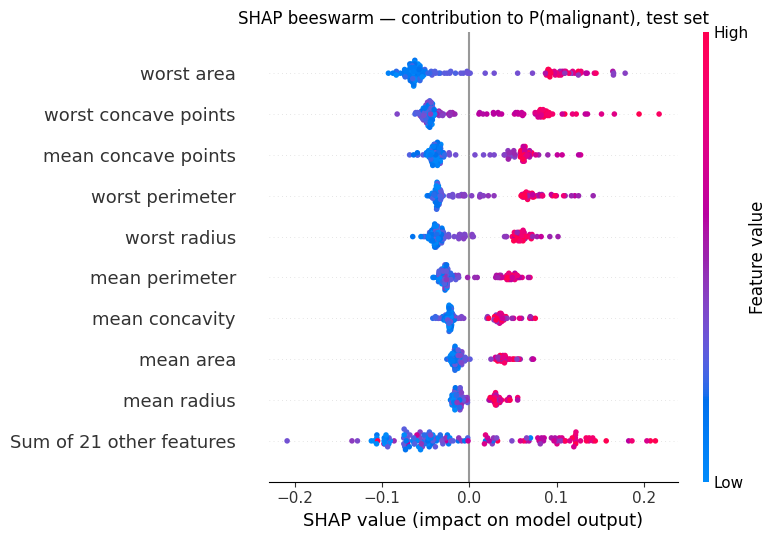

In [4]:
explainer = shap.TreeExplainer(rf)
X_explain = X_test  # 143 rows — small enough to explain exactly
t0 = time.perf_counter()
sv = explainer(X_explain)
shap_seconds = time.perf_counter() - t0

# Slice class 0 = malignant, so positive SHAP values push toward "malignant"
sv_malignant = sv[:, :, 0]
print(f"Explained sample: {X_explain.shape[0]} test patients, {X_explain.shape[1]} features")
print(f"SHAP computation time: {shap_seconds:.2f} s")
print(f"Base value (average P(malignant) over training data): {sv_malignant.base_values[0]:.3f}")

shap_rank = pd.Series(np.abs(sv_malignant.values).mean(axis=0), index=X.columns)
shap_rank = shap_rank.sort_values(ascending=False)

print("\n=== Changed instrument: SHAP mean |value| (top 5 of 30) ===")
for i, (feat, val) in enumerate(shap_rank.head(5).items(), 1):
    print(f"{i}. {feat:<22} {val:.3f}")

overlap_global = set(impurity_rank.head(5).index) & set(shap_rank.head(5).index)
print(f"\nTop-5 overlap with impurity baseline: {len(overlap_global)}/5 features")

shap.plots.beeswarm(sv_malignant, max_display=10, show=False)
plt.title("SHAP beeswarm — contribution to P(malignant), test set")
plt.tight_layout()
plt.show()

**Comparing the two printed rankings:** both instruments agree on the same top-5 set (5/5 overlap) — `worst area`, `worst concave points`, `mean concave points`, `worst perimeter`, `worst radius` — and on the same #1–#3. They disagree only on the order of places 4–5: impurity puts `worst radius` (0.087) above `worst perimeter` (0.080), while SHAP swaps them (`worst perimeter` 0.047 vs `worst radius` 0.043). So for *ranking*, the change of instrument barely mattered here.

What SHAP adds is everything the baseline could not say. In the beeswarm plot, the red (high-value) dots for `worst area` and `worst concave points` sit on the **right** (positive SHAP → pushes toward malignant) and the blue (low-value) dots sit on the left: *large* tumors with *pronounced* concave points make the model predict cancer, which matches medical intuition. Impurity importance could never tell us that direction — and neither ranking can explain one specific patient. That is Step 4.

## Step 4: Local Explanation — Why *This* Patient? (SHAP Waterfall)

Global rankings answer "what does the model care about on average?" The doctor's question is different: "why did the model call **my patient** malignant?" The waterfall plot below reads bottom-up: start at the base value (the average P(malignant)), add this patient's signed feature contributions one by one, and land exactly on the model's prediction for this patient.

=== SHAP explanation for test patient 1 ===
Base value:              0.372
Sum of 30 SHAP values:  +0.628
= Predicted P(malignant): 1.000

Top 5 contributions (signed, probability units):
  worst area             +0.107   (patient value: 1349.00)
  worst concave points   +0.093   (patient value: 0.20)
  worst perimeter        +0.071   (patient value: 138.10)
  mean concave points    +0.063   (patient value: 0.09)
  worst radius           +0.059   (patient value: 21.08)

Context: this patient's worst area = 1349 vs dataset mean = 881


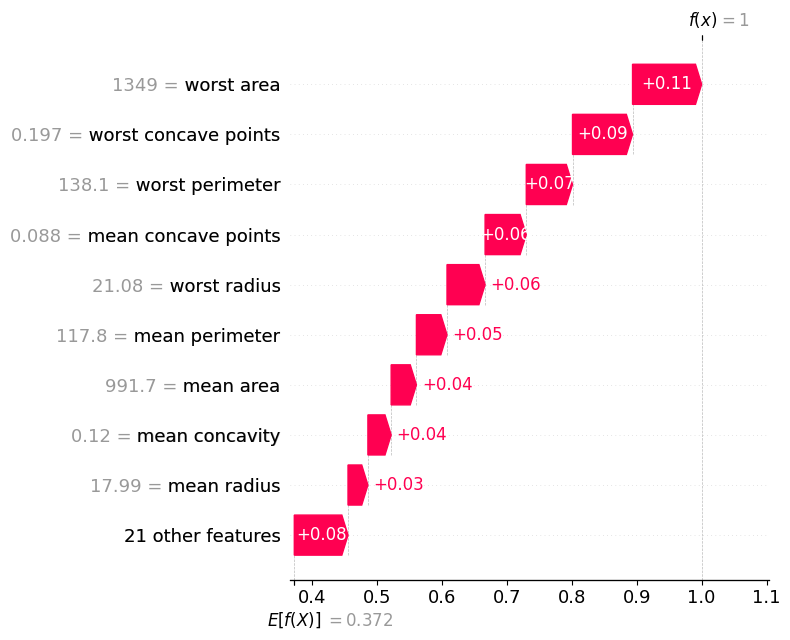

In [5]:
patient_sv = sv_malignant[patient_idx]
contrib = pd.Series(patient_sv.values, index=X.columns)
shap_top5 = contrib.reindex(contrib.abs().sort_values(ascending=False).index).head(5)

print(f"=== SHAP explanation for test patient {patient_idx} ===")
print(f"Base value:              {patient_sv.base_values:.3f}")
print(f"Sum of 30 SHAP values:  +{contrib.sum():.3f}")
print(f"= Predicted P(malignant): {patient_sv.base_values + contrib.sum():.3f}")
print("\nTop 5 contributions (signed, probability units):")
for feat, val in shap_top5.items():
    print(f"  {feat:<22} {val:+.3f}   (patient value: {patient.loc[feat]:.2f})")
print(f"\nContext: this patient's worst area = {patient.loc['worst area']:.0f}"
      f" vs dataset mean = {X['worst area'].mean():.0f}")

shap.plots.waterfall(patient_sv, max_display=10, show=False)
plt.tight_layout()
plt.show()

**Reading the actual waterfall:** the model starts at the base rate P(malignant) = 0.372 and ends at 1.00 for this patient. Every top contribution is positive — `worst area` (+0.107), `worst concave points` (+0.093), `worst perimeter` (+0.071), `mean concave points` (+0.063), `worst radius` (+0.059) — a unanimous push: this tumor is large (worst area 1349 vs the printed dataset mean of 881) *and* has pronounced concave points. That sentence is an explanation a clinician can check against the scan; "P = 1.00" alone was not.

## Step 5: Change One Thing Again — Explain the Same Patient with LIME

Now we keep the model *and* the patient fixed and swap the explanation method. LIME (Local Interpretable Model-agnostic Explanations) knows nothing about trees: it generates thousands of perturbed copies of the patient, queries the model on each, and fits a small weighted linear model around the patient. Its output is a set of human-readable *rules* with weights, rather than exact additive values. If two methods with completely different mechanics point at the same features, our confidence in the explanation rises.

In [6]:
lime_explainer = lime.lime_tabular.LimeTabularExplainer(
    X_train.values,
    feature_names=list(X.columns),
    class_names=list(data.target_names),
    discretize_continuous=True,
    random_state=42,
)
lime_exp = lime_explainer.explain_instance(
    patient.values, rf.predict_proba, num_features=5, labels=(0,)
)
lime_pairs = lime_exp.as_list(label=0)  # weights toward class 0 = malignant

print(f"=== LIME explanation for the same patient (test row {patient_idx}) ===")
for rule, weight in lime_pairs:
    print(f"  {rule:<30} {weight:+.3f}")

# Map each LIME rule back to its base feature name (longest name that appears in the rule)
def base_feature(rule):
    return max((f for f in X.columns if f in rule), key=len)

comparison = pd.DataFrame({
    "SHAP feature": shap_top5.index,
    "SHAP value": [f"{v:+.3f}" for v in shap_top5.values],
    "LIME rule": [r for r, _ in lime_pairs],
    "LIME weight": [f"{w:+.3f}" for _, w in lime_pairs],
}, index=pd.RangeIndex(1, 6, name="rank"))

print("\n=== SHAP vs LIME, same model, same patient ===")
print(comparison.to_string())

overlap_local = set(shap_top5.index) & {base_feature(r) for r, _ in lime_pairs}
print(f"\nTop-5 feature overlap: {len(overlap_local)}/5")

=== LIME explanation for the same patient (test row 1) ===
  worst area > 1034.25           +0.157
  worst concave points > 0.16    +0.123
  worst perimeter > 124.97       +0.110
  worst radius > 18.55           +0.087
  mean concave points > 0.07     +0.071

=== SHAP vs LIME, same model, same patient ===
              SHAP feature SHAP value                    LIME rule LIME weight
rank                                                                          
1               worst area     +0.107         worst area > 1034.25      +0.157
2     worst concave points     +0.093  worst concave points > 0.16      +0.123
3          worst perimeter     +0.071     worst perimeter > 124.97      +0.110
4      mean concave points     +0.063         worst radius > 18.55      +0.087
5             worst radius     +0.059   mean concave points > 0.07      +0.071

Top-5 feature overlap: 5/5


**Comparing the printed table:** the two methods name the **same 5 features (5/5 overlap)** and agree exactly on the top 3 — `worst area`, `worst concave points`, `worst perimeter` — with every weight positive (toward malignant) in both columns. They differ only in ranks 4–5 (SHAP: `mean concave points` then `worst radius`; LIME: `worst radius` then `mean concave points`) and in *vocabulary*: SHAP says "`worst area` contributed +0.107 probability"; LIME says "because `worst area > 1034.25`" — a threshold rule that is often easier to hand to a non-technical decision maker. Two independent instruments, one story: this prediction rests on tumor size and concavity, not on some accidental feature.

## 🧭 Wrap-Up: Global vs Local, and Honest Limits

| Question | Scope | Tool in this notebook |
|---|---|---|
| "What does the model rely on overall?" | **Global** | Impurity importance, SHAP mean \|value\|, beeswarm |
| "Why this patient / this loan applicant?" | **Local** | SHAP waterfall, LIME rules |

Global explanations audit the model (is it using sensible features?); local explanations justify individual decisions (the doctor's and the regulator's question). You usually need both.

**Limitations — be honest about what we just did.** SHAP and LIME explain *the model*, not *reality*: they faithfully report what the random forest keys on, even if the model itself learned a spurious shortcut, and correlated features (here `worst radius`, `worst perimeter`, and `worst area` are near-duplicates of one another) split credit among themselves in ways that can shuffle rankings — exactly the ranks 4–5 disagreements we observed. LIME's answer additionally depends on its random perturbations and discretization thresholds (we fixed `random_state=42`; a different seed can reorder close features), while SHAP's additivity is exact for trees but computing it for large non-tree models requires approximation. None of these values are causal claims: "worst area pushed P(malignant) up by +0.107" describes this classifier's arithmetic, not what would happen to the patient if the tumor shrank. Explanations make models auditable — they do not make them right.